In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

a = np.ones([2], dtype="uint8")                             # Created an array, size 2, with two numbers [1, 1]

b = a * 100                                                 # Array [100, 100]

print(b)
print(b + 155)
print(b + 156)

[100 100]
[255 255]
[0 0]


In [3]:
m1 = np.array([[150, 155], [156, 157]], dtype = "uint8")
m2 = np.ones([2, 2], dtype = "uint8") * 100
print("m1:")
print(m1)
print("m2:")
print(m2)
print("m1+m2:")
print(m1 + m2) # bit overflow happens, 156+100=256 converts into 0, while 157+100=257 becomes 1, becuase one bit is overflowing
# uint8 can hold up to 256 digits hence when we are reaching 256 and range is 0-255 we go down to zero, while 256+ becomes overflowing numbers


m1:
[[150 155]
 [156 157]]
m2:
[[100 100]
 [100 100]]
m1+m2:
[[250 255]
 [  0   1]]


In [4]:
m1 = np.array([[150, 155], [156, 157]], dtype = "uint8")
m2 = np.ones([2, 2], dtype = "uint8") * 100

m1_modified = m1.astype('int16') + m2
m1_modified = np.minimum(m1_modified, 255)   # whenever we go higher than 255, make that number 255
m1_modified = m1_modified.astype('uint8')
m1_modified

array([[250, 255],
       [255, 255]], dtype=uint8)

In [5]:
value_to_add = 100
max_treshold = 255 - 100  # any value bigger than 155 when added 100 will create a bit overflow, hence treshold is 155

m1[m1 >= max_treshold] = 255
m1[m1 < max_treshold] += value_to_add

m1

array([[250, 255],
       [255, 255]], dtype=uint8)

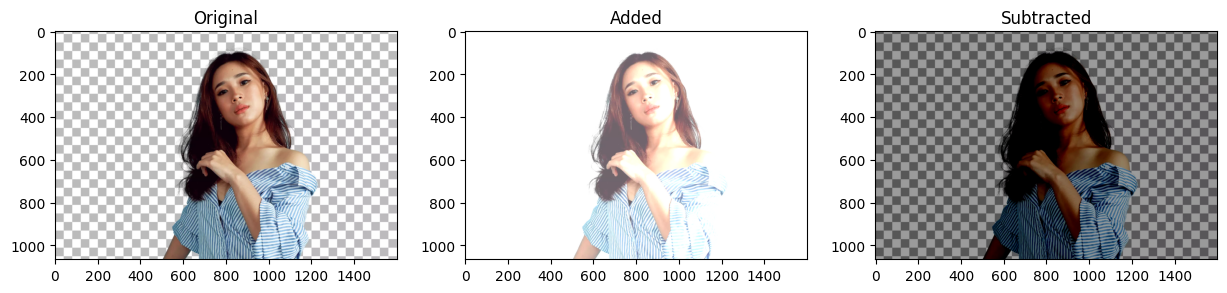

In [6]:
image = cv2.imread("../data/benchmarks/lady.png")

M = np.ones(image.shape, dtype = "uint8") * 100        # we are creating same sized image to use it as value that we can subtract from the whole image

added = cv2.add(image, M)
subtracted = cv2.subtract(image, M)

plt.figure(figsize=[15,5])
plt.subplot(131);plt.imshow(image[...,::-1]);plt.title("Original");
plt.subplot(132);plt.imshow(added[...,::-1]);plt.title("Added");
plt.subplot(133);plt.imshow(subtracted[...,::-1]);plt.title("Subtracted");


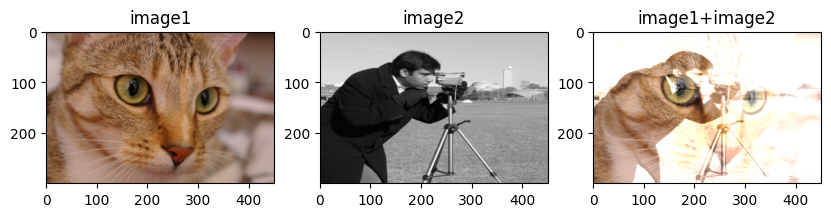

In [7]:
img1 = cv2.imread("../data/benchmarks/cat.png")
img2 = cv2.imread("../data/benchmarks/camera.png")
h, w = img1.shape[:2]

img2_modified = cv2.resize(img2, (w, h))

added = cv2.add(img1, img2_modified)

plt.figure(figsize=[10,5])
plt.subplot(131);plt.imshow(img1[...,::-1]);plt.title("image1");
plt.subplot(132);plt.imshow(img2_modified[...,::-1]);plt.title("image2");
plt.subplot(133);plt.imshow(added[...,::-1]);plt.title("image1+image2");

In [8]:
print(img1.shape)
print(img2.shape)

(300, 451, 3)
(512, 512, 3)


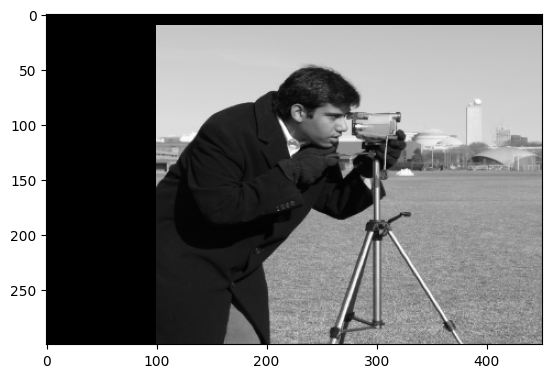

In [9]:
h, w, _ = img1.shape

location_h = 10
location_w = 100

# Check how much room you actually have
available_h = h - location_h # e.g., 300 - 10 = 290
available_w = w - location_w # e.g., 451 - 90 = 361

img2_resized = cv2.resize(img2, (available_w, available_h))

padded_img2 = np.zeros_like(img1)
padded_img2[location_h:location_h+available_h, location_w:location_w+available_w,:] = img2_resized

plt.imshow(padded_img2[...,::-1])

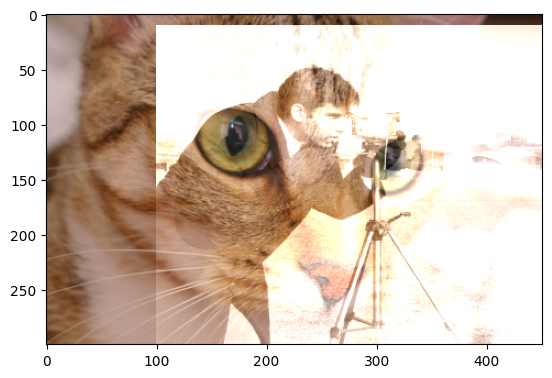

In [10]:
output_image = cv2.add(img1,padded_img2)
plt.imshow(output_image[...,::-1])

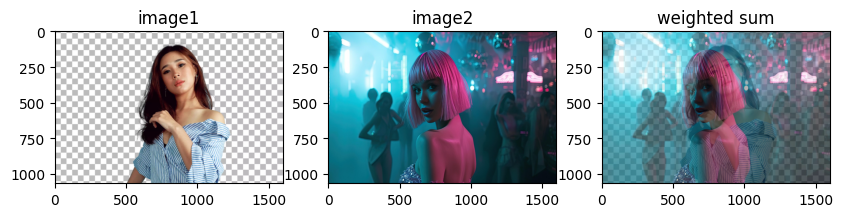

In [15]:
img1 = cv2.imread("../data/benchmarks/lady.png")
h, w = img1.shape[:2]
img2 = cv2.resize(cv2.imread("../data/benchmarks/neonlady.png"), (w, h))

output_image = cv2.addWeighted(img1, 0.3, img2, 0.7, 0)   # Output = (Image1 * alpha) + (Image2 * beta) + gamma
# Alpha and beta are the weights of the image in the final result, meaning which one will be more visible than the other

plt.figure(figsize=[10,5])
plt.subplot(131);plt.imshow(img1[...,::-1]);plt.title("image1");
plt.subplot(132);plt.imshow(img2[...,::-1]);plt.title("image2");
plt.subplot(133);plt.imshow(output_image[...,::-1]);plt.title("weighted sum");

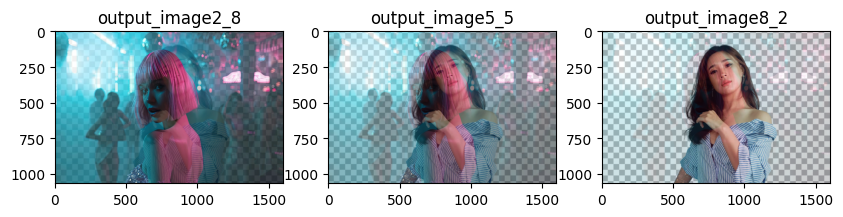

In [16]:
output_image2_8 = cv2.addWeighted(img1,0.2,img2,0.8,0)
output_image5_5 = cv2.addWeighted(img1,0.5,img2,0.5,0)
output_image8_2 = cv2.addWeighted(img1,0.8,img2,0.2,0)

plt.figure(figsize=[10,5])
plt.subplot(131);plt.imshow(output_image2_8[...,::-1]);plt.title("output_image2_8");
plt.subplot(132);plt.imshow(output_image5_5[...,::-1]);plt.title("output_image5_5");
plt.subplot(133);plt.imshow(output_image8_2[...,::-1]);plt.title("output_image8_2");